# Example Usage of SpliceSeqExtractor Class

Below is an example usage for the SpliceSeqExtractor class. Using the motifs functionality from Biopython, and plotting functionality from logomaker, we can get a good idea of the information content in our extracted sequences! First, let's import the necessary libraries. Note that I have included an import from logomaker, which isn't a necessary dependency for protisplice. However, it is a neat way to visualize the motifs. It can simply be installed with pip: `pip install logomaker`.

In [ ]:
from itertools import islice
from Bio.Seq import Seq
import logomaker
from splice_seq_extractor import SpliceSeqExtractor, ExtractionParams, JunctionType
from motif_discovery.motif_scoring import generate_pfm, generate_ppm, generate_pwm

For the data, I used gencode v48 human, chromosome 1. This class should work with any GFF3 and FASTA from any species, provided that you're using the same version numbers for both files (else the annotations won't match the proper coordinates). Of course, annotation quality is going to vary between species, especially for those that aren't very well-studied. GENCODE doesn't provide per-chromosome annotations as separate files, so I will include some simple bash scripts that will split out the whole genome by chromosome, located in `protisplice/bash_utils`.

First, we can instantiate the class. Note that the gff path and FASTA paths are required arguments, and the transcript filter is optional. By default, the transcript filter is `"all"`, but we can filter by transcripts that are considered protein coding by the annotation file with `"protein_coding"`.


In [2]:
params = ExtractionParams(n_exon=10, n_intron=10)
extractor = SpliceSeqExtractor(gff_path="data/input/chr1.gff3", fasta_path="data/input/chr1.fa", transcript_filter="protein_coding", params=params)


By default, the number of exon bases to include is 40, and 80 for intron bases (making a window size of 120). I've opted to use a smaller window with 10 intron and 10 exon bases so we can visualize the motifs for donor and acceptor sequences. We can double check the parameters provided with `get_info()`:

In [3]:
extractor.get_info()

{'window_size': 20,
 'exon_bases': 10,
 'intron_bases': 10,
 'buffer_size': 50,
 'transcript_count': 186320,
 'junction_count': 1725268}

The extractor has two properties - `junctions` and `transcripts`. These are lazy-loaded, so they will be computed upon any method that requires these properties. These properties are also cached as well. First, we can take a look at the identified junctions:

In [4]:
junctions = extractor.junctions

The junctions are generated using a `SpliceJunction` object, which essentially is just a dictionary containing the transcript ID, sequence ID (usually going to be the chromosome # for most purposes), the coordinate of the junction, strand, and the type of junction - either donor or acceptor.

Note that the junction coordinates are 1-based and represent the first exon base along the junction (i.e. coord - 1 is the end of the intron). 

Currently there is a big limitation in the determination of donor/acceptor sites in that they don't take alternative splicing into account. Later I might find some sort of way to correct this using an alt splicing DB or RNA-seq data. For now, just note that the first exon of a transcript is always only a donor, the last one is only an acceptor, and anything in between can be either donor or acceptor. 

Lastly, the transcript ID is suffixed with ID_junctype_num, where junctype is either donor/acceptor, and num is the sequential order in which each splice junction is found, starting at 0. 

In [5]:
junctions[:5]

[SpliceJunction(id='ENST00000832824_donor_0', seqid='chr1', coord=11211, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.DONOR: 'donor'>),
 SpliceJunction(id='ENST00000832824_acceptor_1', seqid='chr1', coord=12010, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.ACCEPTOR: 'acceptor'>),
 SpliceJunction(id='ENST00000832824_donor_1', seqid='chr1', coord=12227, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.DONOR: 'donor'>),
 SpliceJunction(id='ENST00000832824_acceptor_2', seqid='chr1', coord=12613, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.ACCEPTOR: 'acceptor'>),
 SpliceJunction(id='ENST00000832824_donor_2', seqid='chr1', coord=12721, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.DONOR: 'donor'>)]

We can also take a look at all of the transcripts found using `extractor.transcripts`, which will return a `Transcript` object, a dictionary of dictionaries. `Transcript.info` contains the sequence ID from the associated FASTA and the strand type. 

`Transcript.exons` contains the 1-based start and end coordinates for every exon in the transcript. `Transcript.introns` is initiated to `None` but can be determined using `Transcript.get_intron_coords`. 

Reason for this being that the introns can already be inferred from the exon coordinates, and it would take up more memory to explicitly hold the intron coordinates as well, but the method exists if you need it.

In [6]:
transcripts = extractor.transcripts
dict(islice(transcripts.items(), 5))

{'ENST00000832824': Transcript(info=TranscriptInfo(seqid='chr1', strand=<StrandType.POSITIVE: '+'>), exons=[(11121, 11211), (12010, 12227), (12613, 12721), (13453, 14413)], introns=None),
 'ENST00000832825': Transcript(info=TranscriptInfo(seqid='chr1', strand=<StrandType.POSITIVE: '+'>), exons=[(11125, 11211), (12010, 12227), (12613, 12721), (13403, 14405)], introns=None),
 'ENST00000832826': Transcript(info=TranscriptInfo(seqid='chr1', strand=<StrandType.POSITIVE: '+'>), exons=[(11410, 11671), (12010, 12227), (12595, 12721), (13483, 14413)], introns=None),
 'ENST00000832827': Transcript(info=TranscriptInfo(seqid='chr1', strand=<StrandType.POSITIVE: '+'>), exons=[(11411, 11671), (12010, 12227), (12613, 12721), (13483, 14413)], introns=None),
 'ENST00000832828': Transcript(info=TranscriptInfo(seqid='chr1', strand=<StrandType.POSITIVE: '+'>), exons=[(11426, 11671), (12010, 12227), (12613, 12721), (13221, 14409)], introns=None)}

Lastly, we will get to the bigger workflow functions from this class. `extract_splice_sites` will return a JunctionData object containing the splice junction, window start, window end, and the sequence.

In [7]:
true_ss = extractor.sequence_extractor.extract_splice_sites(junctions)
true_ss[:5]

[JunctionData(junction=SpliceJunction(id='ENST00000832824_donor_0', seqid='chr1', coord=11211, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.DONOR: 'donor'>), window_start=11202, window_end=11221, sequence='CTTGCTCACGGTGCTGTGCC'),
 JunctionData(junction=SpliceJunction(id='ENST00000832824_acceptor_1', seqid='chr1', coord=12010, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.ACCEPTOR: 'acceptor'>), window_start=12000, window_end=12019, sequence='TCATCTGCAGGTGTCTGACT'),
 JunctionData(junction=SpliceJunction(id='ENST00000832824_donor_1', seqid='chr1', coord=12227, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.DONOR: 'donor'>), window_start=12218, window_end=12237, sequence='ACCTAGGCCAGTAAGTAGTG'),
 JunctionData(junction=SpliceJunction(id='ENST00000832824_acceptor_2', seqid='chr1', coord=12613, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.ACCEPTOR: 'acceptor'>), window_start=12603, window_end=12622, sequence='CTCCCCCCAGGTGT

In [8]:
true_ss[1].sequence

'TCATCTGCAGGTGTCTGACT'

To visualize the different motifs between donors and acceptors, we'll split the sequences based on their junction type into two lists using a simple list comprehension. 

In [9]:
acceptors = [true_ss[x].sequence for x in range(len(true_ss)) if true_ss[x].junction.junction_type == JunctionType.ACCEPTOR]
# acceptors[:5]

donors = [true_ss[x].sequence for x in range(len(true_ss)) if true_ss[x].junction.junction_type == JunctionType.DONOR]
donors[:5]

['CTTGCTCACGGTGCTGTGCC',
 'ACCTAGGCCAGTAAGTAGTG',
 'TGTTGCAGAGGTGAGAGGAG',
 'CTTGCTCACGGTGCTGTGCC',
 'ACCTAGGCCAGTAAGTAGTG']

Now we can see a cool use case for the SpliceSeqExtractor class! In addition to the sequence extraction methods, I have also provided methods to generate position frequency, weight, and probability matrices from a list of sequences. All of these methods will return a pandas DataFrame, where the columns are the nucleotides A, T, G, C, and the values represent either the count, log-odds ratio, or the probability of each nucleotide at each position.  

These are useful for finding motifs in aligned sequences. As an example, we can see the differences in motifs between donor and acceptor sequences below!



In [10]:
donors_seqs = [Seq(s) for s in donors]
acceptors_seqs = [Seq(s) for s in acceptors]

ppm_donors = generate_ppm(donors_seqs)
ppm_acceptors = generate_ppm(acceptors_seqs)

Now, we can pass in our dataframes into `logomaker` to visualize our motifs!

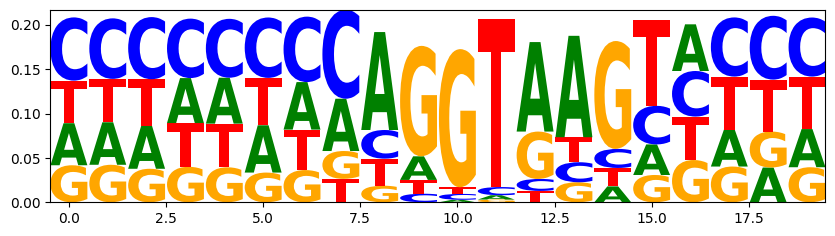

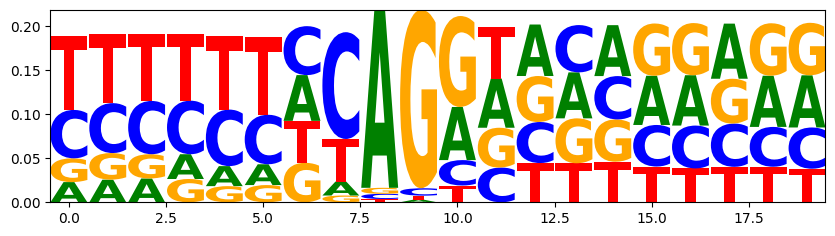

In [12]:
logomaker.Logo(ppm_donors, color_scheme='classic')
logomaker.Logo(ppm_acceptors, color_scheme='classic')

From the chromosome 1 data, we can see that the donor motif shows G/T at positions 10/11 and the acceptor motif has A/G at positions 8/9. This is what we would expect the consensus to be for human splice sites. You could use this class and workflow to look for other motifs as well, like branch point sequences (BPS), or compare the conservation of these motifs across organisms. Hopefully you find this useful!